# Modélisation v7 — GBS + Airport Feature

## Objectif
Tester si l'ajout de l'identifiant d'aéroport (encodé) améliore le C-index vs v6.

## Changement vs v6
- **Nouvelle feature** : `airport_enc` (LabelEncoder sur les 5 aéroports)
- Même architecture GBS, mêmes hyperparamètres
- Même split train 2016-2020 / test 2021-2022

## Référence v6
- C-index train : 0.7755
- C-index test  : 0.7410

In [1]:
import time
import numpy as np
import pandas as pd
import joblib
import json
from datetime import datetime
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sksurv.util import Surv
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

print('Imports OK')

Imports OK


In [2]:
DATA_DIR = Path('../data')
df = pd.read_parquet(DATA_DIR / 'data_df_with_alert.parquet')
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.sort_values(['airport', 'airport_alert_id', 'date']).reset_index(drop=True)

print(f'Données chargées : {len(df):,} éclairs')
print(f'Aéroports        : {sorted(df["airport"].unique())}')
print(f'Période          : {df["date"].min().date()} → {df["date"].max().date()}')

Données chargées : 56,599 éclairs
Aéroports        : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise']
Période          : 2016-01-02 → 2022-12-16


In [3]:
def build_survival(df, max_gap=30):
    df = df.copy()
    df = df.sort_values(['airport', 'airport_alert_id', 'date'])
    g = df.groupby(['airport', 'airport_alert_id'])
    df['next_date'] = g['date'].shift(-1)
    df['duree'] = (df['next_date'] - df['date']).dt.total_seconds() / 60
    df['event'] = df['duree'].notna() & (df['duree'] <= max_gap)
    df.loc[~df['event'], 'duree'] = max_gap
    df['duree'] = df['duree'].clip(lower=0.01)
    return df

df = build_survival(df)
print(f"Events : {df['event'].sum():,} / {len(df):,} ({df['event'].mean()*100:.1f}%)")

Events : 53,972 / 56,599 (95.4%)


In [4]:
df['annee'] = df['date'].dt.year
df_train = df[df['annee'] <= 2020].copy()
df_test  = df[df['annee'] >= 2021].copy()

print(f'Train : {len(df_train):,} éclairs ({df_train["annee"].min()}–{df_train["annee"].max()})')
print(f'Test  : {len(df_test):,} éclairs ({df_test["annee"].min()}–{df_test["annee"].max()})')
print()
print('Distribution par aéroport :')
print(pd.concat([
    df_train['airport'].value_counts().rename('train'),
    df_test['airport'].value_counts().rename('test')
], axis=1))

Train : 41,509 éclairs (2016–2020)
Test  : 15,090 éclairs (2021–2022)

Distribution par aéroport :
          train  test
airport              
Pise      13483  4438
Bastia     9018  4724
Ajaccio    8626  2021
Biarritz   7704  2207
Nantes     2678  1700


In [5]:
def build_features_v7(df_tr, df_te):
    """Feature engineering v7 : identique v6 + airport_enc."""

    # --- Label encoder aéroport : FIT sur train uniquement ---
    le = LabelEncoder()
    le.fit(df_tr['airport'])
    print(f'Classes aéroport : {list(le.classes_)} → {list(range(len(le.classes_)))}')

    result = []
    for df in [df_tr, df_te]:
        d = df.copy()

        # Temporelles
        h = d['date'].dt.hour + d['date'].dt.minute / 60
        d['h_cos']   = np.cos(2 * np.pi * h / 24)
        d['h_sin']   = np.sin(2 * np.pi * h / 24)
        doy = d['date'].dt.dayofyear
        d['doy_cos'] = np.cos(2 * np.pi * doy / 365)
        d['doy_sin'] = np.sin(2 * np.pi * doy / 365)
        d['saison']  = ((d['date'].dt.month % 12) // 3) + 1

        # Silence / fréquence
        g = d.groupby(['airport', 'airport_alert_id'])
        prev = g['date'].shift(1)
        d['silence_min'] = ((d['date'] - prev).dt.total_seconds() / 60).fillna(30).clip(0, 60)
        d['freq_5min']   = (1 / d['silence_min'].clip(lower=0.5)).clip(upper=10)

        # Distance
        d['dist_centre']     = d['dist']
        d['dist_avg_5']      = g['dist'].transform(lambda x: x.rolling(5, min_periods=1).mean())
        d['dist_min_so_far'] = g['dist'].cummin()

        # Maturité alerte
        d['rang']      = g.cumcount()
        d['rang_norm'] = d['rang'] / g['rang'].transform('max').clip(lower=1)

        # ── NOUVEAU v7 : identifiant aéroport ──
        d['airport_enc'] = le.transform(d['airport'])

        result.append(d)

    features_v7 = [
        'h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison',
        'dist_centre', 'dist_avg_5', 'dist_min_so_far',
        'silence_min', 'freq_5min', 'rang', 'rang_norm',
        'airport_enc',   # ← nouveauté v7
    ]

    # Imputation
    for col in features_v7:
        for d in result:
            if d[col].isna().any():
                d[col] = d[col].fillna(d[col].median())

    return result[0], result[1], features_v7, le


df_train, df_test, FEATURES_V7, le = build_features_v7(df_train, df_test)
print(f'\nFeatures v7 ({len(FEATURES_V7)}) : {FEATURES_V7}')

Classes aéroport : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise'] → [0, 1, 2, 3, 4]

Features v7 (13) : ['h_cos', 'h_sin', 'doy_cos', 'doy_sin', 'saison', 'dist_centre', 'dist_avg_5', 'dist_min_so_far', 'silence_min', 'freq_5min', 'rang', 'rang_norm', 'airport_enc']


In [6]:
y_train = Surv.from_arrays(df_train['event'].values, df_train['duree'].values)
y_test  = Surv.from_arrays(df_test['event'].values,  df_test['duree'].values)

X_train = df_train[FEATURES_V7].values.astype(np.float32)
X_test  = df_test[FEATURES_V7].values.astype(np.float32)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'X_train : {X_train_s.shape}')
print(f'X_test  : {X_test_s.shape}')

X_train : (41509, 13)
X_test  : (15090, 13)


In [7]:
gbs_v7 = GradientBoostingSurvivalAnalysis(
    n_estimators=50,
    learning_rate=0.15,
    max_depth=3,
    subsample=0.9,
    min_samples_leaf=10,
    loss='coxph',
    random_state=42,
)

print('Entraînement GBS v7...')
t0 = time.time()
gbs_v7.fit(X_train_s, y_train)
elapsed = time.time() - t0

c_train = gbs_v7.score(X_train_s, y_train)
c_test  = gbs_v7.score(X_test_s,  y_test)

print(f'Durée         : {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'C-index train : {c_train:.4f}')
print(f'C-index test  : {c_test:.4f}')

Entraînement GBS v7...
Durée         : 1788.7s (29.8 min)
C-index train : 0.7756
C-index test  : 0.7421


In [8]:
# ── COMPARAISON v6 vs v7 ──
C_INDEX_V6_TRAIN = 0.7755
C_INDEX_V6_TEST  = 0.7410

delta_train = c_train - C_INDEX_V6_TRAIN
delta_test  = c_test  - C_INDEX_V6_TEST

print('=' * 50)
print('       COMPARAISON  v6  →  v7')
print('=' * 50)
print(f'C-index train : {C_INDEX_V6_TRAIN:.4f} → {c_train:.4f}  ({delta_train:+.4f})')
print(f'C-index test  : {C_INDEX_V6_TEST:.4f} → {c_test:.4f}  ({delta_test:+.4f})')
print()
if delta_test > 0.002:
    print('✅  v7 AMÉLIORE le C-index test — continuer avec v7')
elif delta_test > 0:
    print('⚠️  v7 améliore très légèrement — gain marginal')
elif delta_test > -0.002:
    print('➡️  v7 neutre — airport_enc n\'apporte pas de signal significatif')
else:
    print('❌  v7 dégrade le C-index — ne pas utiliser')

       COMPARAISON  v6  →  v7
C-index train : 0.7755 → 0.7756  (+0.0001)
C-index test  : 0.7410 → 0.7421  (+0.0011)

⚠️  v7 améliore très légèrement — gain marginal


Calcul permutation importance (peut prendre ~1-2 min)...
        feature    importance      std
           rang  1.023886e-01 0.001916
      rang_norm  4.281227e-02 0.000440
      freq_5min  1.813207e-02 0.001096
    silence_min  1.577153e-02 0.000940
        doy_cos  3.583436e-03 0.000141
        doy_sin  2.579221e-03 0.000214
dist_min_so_far  1.005027e-04 0.000003
          h_cos  3.257429e-05 0.000082
    dist_centre  6.470226e-07 0.000006
    airport_enc -9.345881e-06 0.000008
         saison -2.191939e-05 0.000082
     dist_avg_5 -4.201153e-05 0.000038
          h_sin -1.726011e-03 0.000255


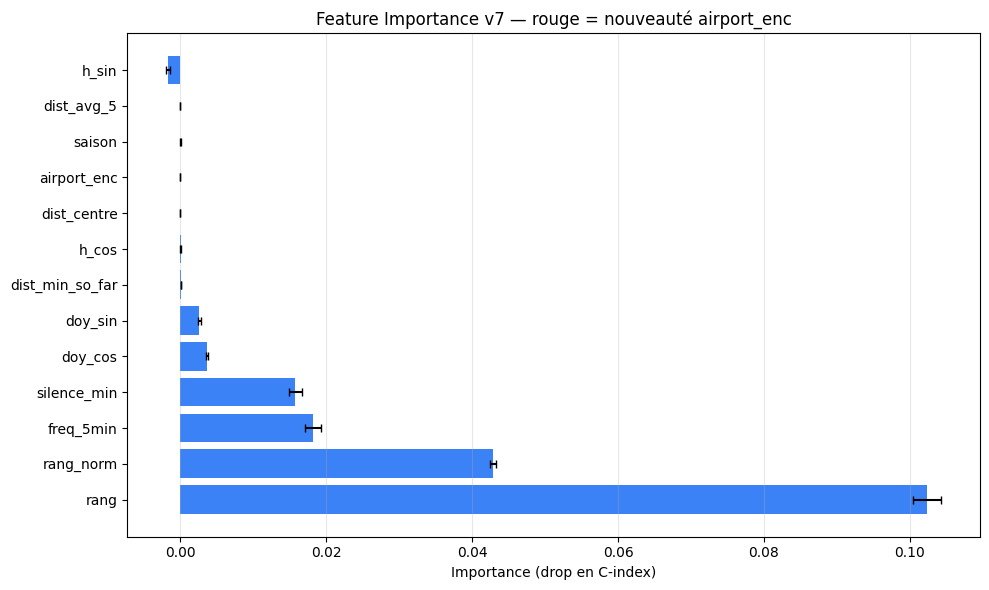


Rang de airport_enc : 13/13


In [9]:
# Importance rapide via staged_predict (gain de score par feature)
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print('Calcul permutation importance (peut prendre ~1-2 min)...')
perm = permutation_importance(
    gbs_v7, X_test_s, y_test,
    n_repeats=3, random_state=42, n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': FEATURES_V7,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False)

print(imp_df.to_string(index=False))

# Mettre airport_enc en évidence
colors = ['#EF4444' if f == 'airport_enc' else '#3B82F6' for f in imp_df['feature']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, xerr=imp_df['std'], capsize=3)
ax.set_xlabel('Importance (drop en C-index)')
ax.set_title('Feature Importance v7 — rouge = nouveauté airport_enc')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

airport_rank = imp_df[imp_df['feature'] == 'airport_enc'].index[0] + 1
print(f"\nRang de airport_enc : {airport_rank}/{len(FEATURES_V7)}")

In [10]:
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(gbs_v7,  MODEL_DIR / 'gbs_v7_model.pkl')
joblib.dump(scaler,  MODEL_DIR / 'gbs_v7_scaler.pkl')
joblib.dump(le,      MODEL_DIR / 'gbs_v7_label_encoder.pkl')

metadata_v7 = {
    'model': 'GBS_v7',
    'features': FEATURES_V7,
    'n_features': len(FEATURES_V7),
    'airports': list(le.classes_),
    'c_index_train': float(c_train),
    'c_index_test':  float(c_test),
    'c_index_v6_train': C_INDEX_V6_TRAIN,
    'c_index_v6_test':  C_INDEX_V6_TEST,
    'delta_test': float(delta_test),
    'train_size': int(len(X_train)),
    'test_size':  int(len(X_test)),
    'date_trained': datetime.now().isoformat(),
    'elapsed_seconds': float(elapsed),
    'hyperparams': {
        'n_estimators': 50,
        'learning_rate': 0.15,
        'max_depth': 3,
        'subsample': 0.9,
        'min_samples_leaf': 10,
        'loss': 'coxph',
    }
}

with open(MODEL_DIR / 'gbs_v7_metadata.json', 'w') as f:
    json.dump(metadata_v7, f, indent=2)

print('Modèles v7 sauvegardés :')
print('  models/gbs_v7_model.pkl')
print('  models/gbs_v7_scaler.pkl')
print('  models/gbs_v7_label_encoder.pkl')
print('  models/gbs_v7_metadata.json')
print()
print(f'C-index test v7 : {c_test:.4f}  (v6 : {C_INDEX_V6_TEST:.4f}  |  Δ = {delta_test:+.4f})')

Modèles v7 sauvegardés :
  models/gbs_v7_model.pkl
  models/gbs_v7_scaler.pkl
  models/gbs_v7_label_encoder.pkl
  models/gbs_v7_metadata.json

C-index test v7 : 0.7421  (v6 : 0.7410  |  Δ = +0.0011)


## Décision

| | v6 | v7 |
|--|--|--|
| Features | 12 | 13 (+airport_enc) |
| C-index train | 0.7755 | *voir résultat* |
| C-index test | 0.7410 | *voir résultat* |

**Si Δ test > +0.002** → on migre vers v7 et on relance l'évaluation 2023.  
**Si Δ test ≈ 0** → airport_enc n'apporte pas de signal, on garde v6.  
**Si Δ test < 0** → la feature bruite le modèle, on abandonne l'idée.